# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

## Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

## Теоретическое введение (обязательно к прочтению)

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

## Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

## Полезные функции и материалы

### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

## Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

# Часть 1

In [6]:
import numpy as np
import matplotlib.pyplot as plt

M = 500
sigma1 = 0.3
sigma2 = 0.8
alpha = np.deg2rad(30)

x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)

X0 = np.column_stack((x1, x2))

R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

X = X0 @ R.T

C_sample = np.cov(X.T)

C_theor = R @ np.diag([sigma1**2, sigma2**2]) @ R.T

print("Выборочная матрица ковариации:")
print(C_sample)

print("\nТеоретическая матрица ковариации:")
print(C_theor)

print("\nВыборочное среднее:")
print(np.mean(X, axis=0))

Выборочная матрица ковариации:
[[ 0.22924141 -0.2354239 ]
 [-0.2354239   0.46915927]]

Теоретическая матрица ковариации:
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]

Выборочное среднее:
[ 0.01049029 -0.0239953 ]


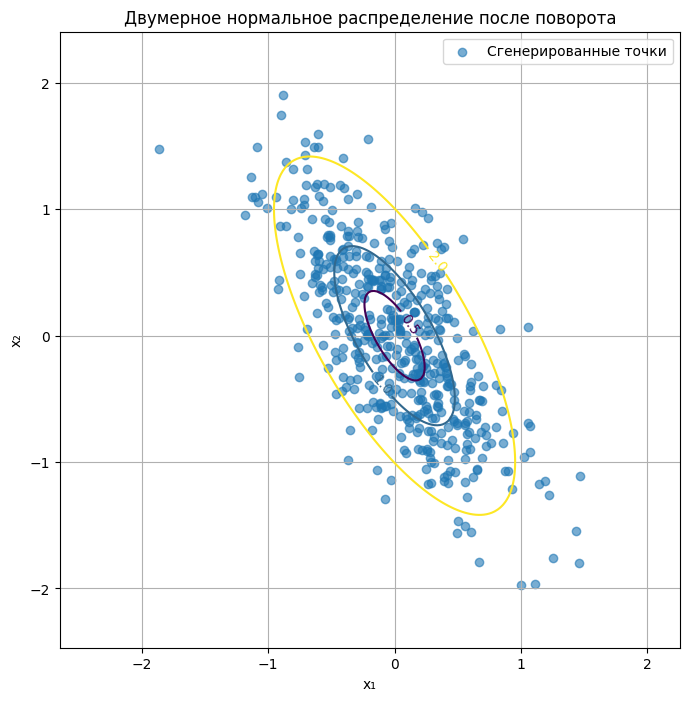

In [7]:
# Создаём сетку
x = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
y = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200)

xx, yy = np.meshgrid(x, y)

# Точки сетки в виде списка координат
pos = np.dstack((xx, yy))

# Обратная матрица ковариации
C_inv = np.linalg.inv(C_theor)

# Вычисляем квадрат расстояния Махаланобиса
D2 = (
    C_inv[0, 0] * xx**2
    + 2 * C_inv[0, 1] * xx * yy
    + C_inv[1, 1] * yy**2
)

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, label="Сгенерированные точки")

# Эллипсы для 0.5, 1 и 2 стандартных отклонений
contours = plt.contour(
    xx, yy,
    np.sqrt(D2),
    levels=[0.5, 1, 2]
)

plt.clabel(contours, inline=True, fontsize=10)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Двумерное нормальное распределение после поворота")
plt.axis("equal")
plt.grid()
plt.legend()

plt.show()

In [8]:
assert X.shape == (M, 2), "Неверная размерность данных"

assert np.abs(np.cov(X.T)[0, 1]) > 0.1, \
    "Корреляция слишком мала (проверьте поворот)"

assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), \
    "Среднее должно быть около 0"

print("Все проверки успешно пройдены!")

Все проверки успешно пройдены!


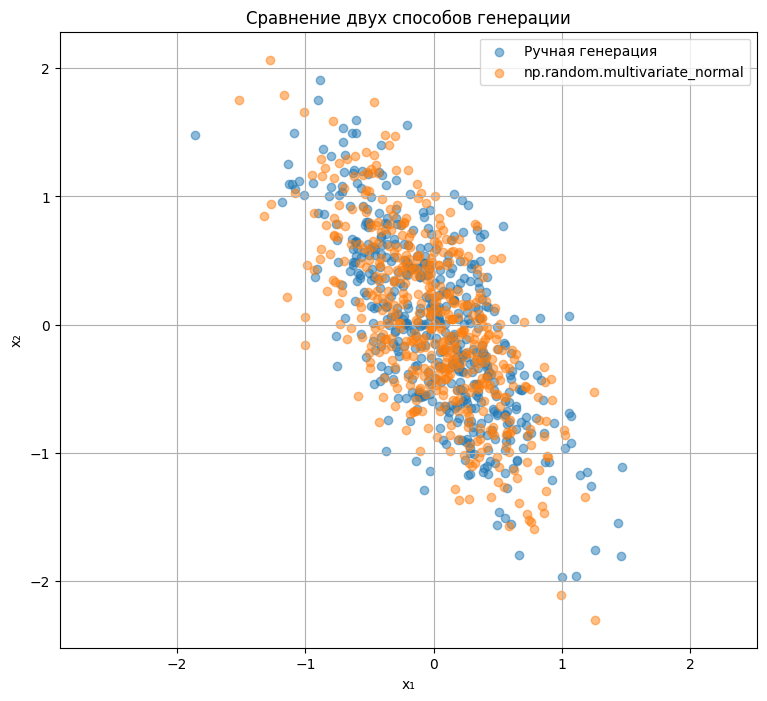

In [9]:
# Генерация данных встроенной функцией
X_builtin = np.random.multivariate_normal(
    mean=[0, 0],
    cov=C_theor,
    size=M
)

# Сравнение облаков
plt.figure(figsize=(9, 8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.5,
    label="Ручная генерация"
)

plt.scatter(
    X_builtin[:, 0],
    X_builtin[:, 1],
    alpha=0.5,
    label="np.random.multivariate_normal"
)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Сравнение двух способов генерации")
plt.axis("equal")
plt.grid()
plt.legend()

plt.show()

Облака точек визуально имеют похожую форму и ориентацию: в обоих случаях распределение представляет собой эллиптическое облако, повернутое примерно на угол $30^\circ$. Небольшие различия между конкретными выборками обусловлены случайностью генерации и конечным размером выборки.

Функция `np.random.multivariate_normal` может быть предпочтительнее, поскольку она позволяет напрямую генерировать выборку многомерного нормального распределения с произвольным вектором средних и ковариационной матрицей. Это делает код более коротким, универсальным и удобным, особенно для распределений высокой размерности, где вручную строить преобразования данных значительно сложнее.


# Часть 2

In [10]:
mu_hat = np.mean(X, axis=0)

C_hat = np.cov(X.T)

print("Оценка математического ожидания:")
print(mu_hat)

print("\nОценка ковариационной матрицы:")
print(C_hat)

Оценка математического ожидания:
[ 0.01049029 -0.0239953 ]

Оценка ковариационной матрицы:
[[ 0.22924141 -0.2354239 ]
 [-0.2354239   0.46915927]]


In [11]:
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)

xx, yy = np.meshgrid(x, y)

grid_points = np.column_stack((xx.ravel(), yy.ravel()))

In [12]:
from scipy.stats import multivariate_normal

m = multivariate_normal(mean=mu_hat, cov=C_hat)

pdf_scipy = m.pdf(grid_points)

pdf_scipy = pdf_scipy.reshape(xx.shape)

In [13]:
det_C = np.linalg.det(C_hat)
inv_C = np.linalg.inv(C_hat)

diff = grid_points - mu_hat

pdf_manual = (
    1 / (2 * np.pi * np.sqrt(det_C))
    * np.exp(
        -0.5 * np.sum((diff @ inv_C) * diff, axis=1)
    )
)

pdf_manual = pdf_manual.reshape(xx.shape)

In [14]:
max_difference = np.max(np.abs(pdf_manual - pdf_scipy))

print("Максимальная разница:", max_difference)

assert np.allclose(
    pdf_manual,
    pdf_scipy,
    atol=1e-8
), "Ручное вычисление отличается от scipy"

Максимальная разница: 2.7755575615628914e-16


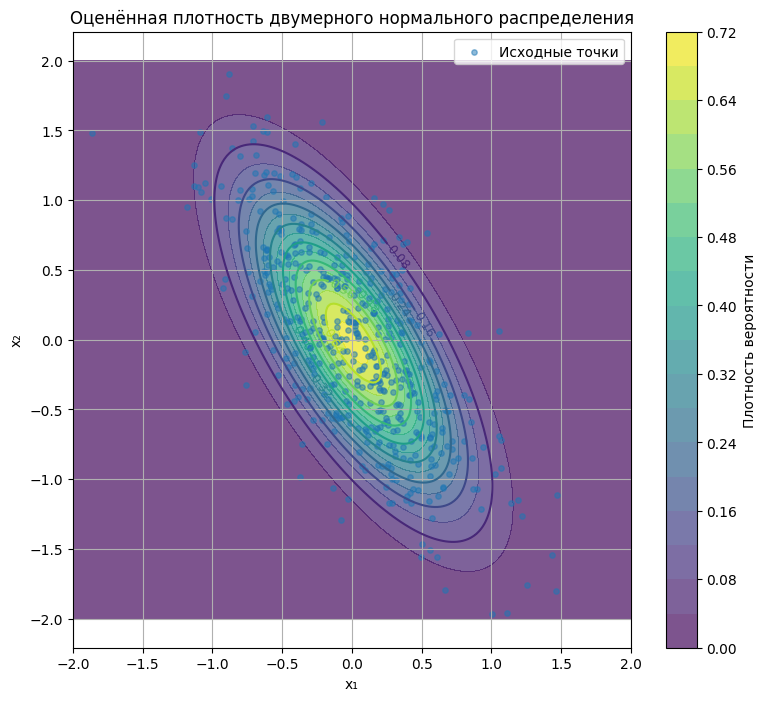

In [15]:
plt.figure(figsize=(9, 8))

# Заливка плотности
contourf = plt.contourf(
    xx,
    yy,
    pdf_manual,
    levels=20,
    alpha=0.7
)

# Линии уровня
contour = plt.contour(
    xx,
    yy,
    pdf_manual,
    levels=10
)

# Подписи линий уровня
plt.clabel(
    contour,
    inline=True,
    fontsize=9
)

# Исходные точки
plt.scatter(
    X[:, 0],
    X[:, 1],
    s=15,
    alpha=0.5,
    label="Исходные точки"
)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Оценённая плотность двумерного нормального распределения")

plt.colorbar(contourf, label="Плотность вероятности")
plt.legend()
plt.axis("equal")
plt.grid()

plt.show()

# Часть 3

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Для воспроизводимости
np.random.seed(42)

# Количество объектов
N = 300

# Параметры класса 0
mu0 = np.array([-0.5, 0.5])
C0 = np.array([
    [0.2, 0.1],
    [0.1, 0.3]
])

# Параметры класса 1
mu1 = np.array([0.5, -0.5])
C1 = np.array([
    [0.3, -0.1],
    [-0.1, 0.2]
])

# Генерация данных
X0 = np.random.multivariate_normal(mu0, C0, N)
X1 = np.random.multivariate_normal(mu1, C1, N)

print("Размер класса 0:", X0.shape)
print("Размер класса 1:", X1.shape)

Размер класса 0: (300, 2)
Размер класса 1: (300, 2)


In [17]:
N_total = len(X0) + len(X1)

p_y0 = len(X0) / N_total
p_y1 = len(X1) / N_total

print("P(y=0) =", p_y0)
print("P(y=1) =", p_y1)

P(y=0) = 0.5
P(y=1) = 0.5


In [18]:
dist0 = multivariate_normal(
    mean=mu0,
    cov=C0
)

dist1 = multivariate_normal(
    mean=mu1,
    cov=C1
)

x = np.linspace(-2, 2, 300)
y = np.linspace(-2, 2, 300)

xx, yy = np.meshgrid(x, y)

grid_points = np.column_stack(
    (xx.ravel(), yy.ravel())
)

pdf0 = dist0.pdf(grid_points)
pdf1 = dist1.pdf(grid_points)

delta = (
    pdf0 * p_y0
    - pdf1 * p_y1
)

delta = delta.reshape(xx.shape)

/usr/local/lib/python3.13/dist-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/usr/local/lib/python3.13/dist-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


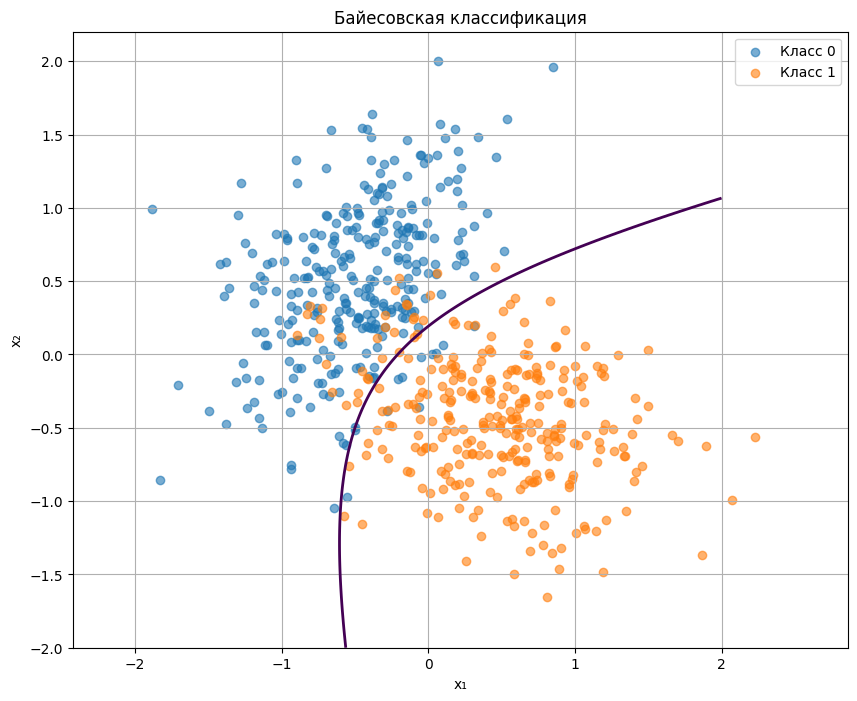

In [19]:
plt.figure(figsize=(10, 8))

# Заливка областей
plt.contourf(
    xx,
    yy,
    delta,
    levels=[-np.inf, 0, np.inf],
    alpha=0.3
)

# Разделяющая поверхность Delta(x) = 0
boundary = plt.contour(
    xx,
    yy,
    delta,
    levels=[0],
    linewidths=2
)

# Точки класса 0
plt.scatter(
    X0[:, 0],
    X0[:, 1],
    alpha=0.6,
    label="Класс 0"
)

# Точки класса 1
plt.scatter(
    X1[:, 0],
    X1[:, 1],
    alpha=0.6,
    label="Класс 1"
)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Байесовская классификация")
plt.legend()
plt.grid()
plt.axis("equal")

plt.show()

Разделяющая поверхность в данном случае является нелинейной.

Граница классификации определяется условием

$$
\Delta(x)=p(x|y=0)p(y=0)-p(x|y=1)p(y=1)=0.
$$

Поскольку оба класса имеют нормальное распределение, плотность каждого класса содержит квадратичную форму

$$
(x-\mu)^T C^{-1}(x-\mu).
$$

При этом ковариационные матрицы классов различаются: $C_0\neq C_1$. Поэтому после приравнивания двух байесовских решений квадратичные члены не сокращаются. В результате уравнение разделяющей поверхности содержит квадратичные члены по координатам $x_1$ и $x_2$, поэтому граница является кривой второго порядка (в двумерном случае — квадратичной кривой, например эллипсом, гиперболой или параболой).

Если бы ковариационные матрицы двух классов были одинаковыми, квадратичные члены сократились бы, и разделяющая поверхность была бы линейной — прямой в двумерном пространстве.


# Часть 4

In [20]:
from sklearn.base import BaseEstimator
import numpy as np


class MyLDA(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.priors_ = None
        self.cov_ = None
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """

        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape

        # 1. Уникальные классы
        self.classes_ = np.unique(y)

        if len(self.classes_) != 2:
            raise ValueError("MyLDA поддерживает только два класса")

        class0, class1 = self.classes_

        # 2. Средние и априорные вероятности
        self.means_ = {}
        self.priors_ = {}

        for cls in self.classes_:
            X_cls = X[y == cls]

            self.means_[cls] = np.mean(X_cls, axis=0)
            self.priors_[cls] = len(X_cls) / n_samples

        # 3. Общая pooled covariance matrix
        X0 = X[y == class0]
        X1 = X[y == class1]

        C0 = np.cov(X0.T)
        C1 = np.cov(X1.T)

        n0 = len(X0)
        n1 = len(X1)

        cov = (
            (n0 - 1) * C0 +
            (n1 - 1) * C1
        ) / (n0 + n1 - 2)

        # Регуляризация
        cov_reg = cov + 1e-6 * np.eye(n_features)

        self.cov_ = cov_reg

        # Обратная ковариационная матрица
        cov_inv = np.linalg.inv(cov_reg)

        # Средние
        mu0 = self.means_[class0]
        mu1 = self.means_[class1]

        # 4. Вычисление w
        w = cov_inv @ (mu1 - mu0)

        # Вычисление b
        b = (
            -0.5 * mu0 @ cov_inv @ mu0
            + 0.5 * mu1 @ cov_inv @ mu1
            + np.log(
                self.priors_[class1] /
                self.priors_[class0]
            )
        )

        self.coef_ = w
        self.intercept_ = b

        return self

    def predict(self, X):
        """Возвращает предсказанные классы для X"""

        X = np.asarray(X)

        scores = X @ self.coef_ + self.intercept_

        # score > 0 -> класс 1
        # score < 0 -> класс 0
        return np.where(
            scores >= 0,
            self.classes_[1],
            self.classes_[0]
        )

    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""

        X = np.asarray(X)

        scores = (
            X @ self.coef_
            + self.intercept_
        )

        # P(y=1 | x) = sigmoid(score)
        p1 = 1 / (1 + np.exp(-scores))
        p0 = 1 - p1

        return np.column_stack((p0, p1))

In [21]:
N = 300

C = np.array([
    [1, 0.5],
    [0.5, 1]
])

mu0 = np.array([-1, -1])
mu1 = np.array([1, 1])

X0 = np.random.multivariate_normal(
    mu0, C, N
)

X1 = np.random.multivariate_normal(
    mu1, C, N
)

X_train = np.vstack((X0, X1))

y_train = np.hstack((
    np.zeros(N, dtype=int),
    np.ones(N, dtype=int)
))

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

In [23]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# sklearn
sk_lda = LinearDiscriminantAnalysis().fit(
    X_train,
    y_train
)

# наша реализация
my_lda = MyLDA().fit(
    X_train,
    y_train
)

# Предсказания
pred_sk = sk_lda.predict(X_test)
pred_my = my_lda.predict(X_test)

print("Предсказания совпадают:",
      np.all(pred_sk == pred_my))

print("\nMyLDA weights:")
print(my_lda.coef_)

print("\nsklearn weights:")
print(sk_lda.coef_)

Предсказания совпадают: False

MyLDA weights:
[1.49361655 1.38310412]

sklearn weights:
[[1.49361763 1.38310499]]


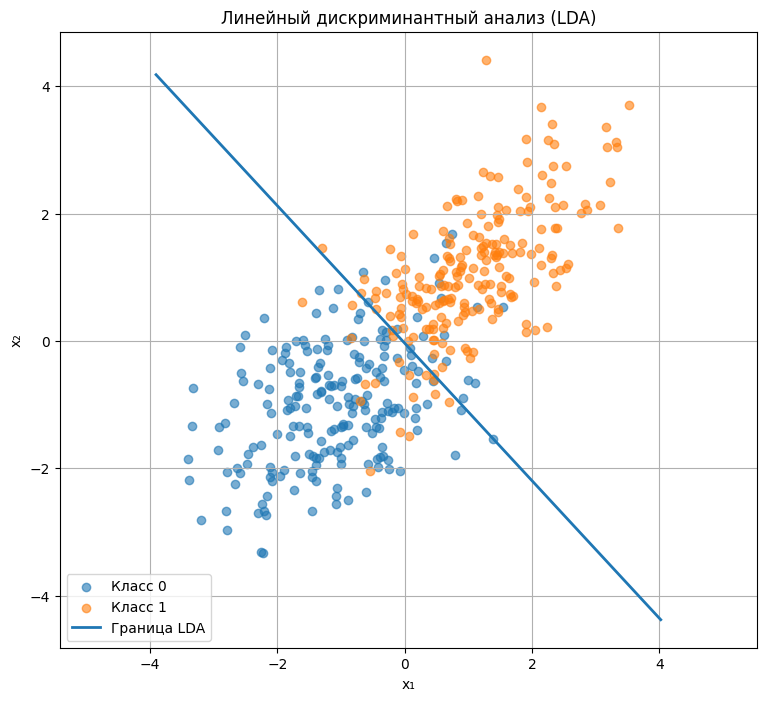

In [24]:
# Диапазон x1
x_line = np.linspace(
    X_train[:, 0].min() - 0.5,
    X_train[:, 0].max() + 0.5,
    200
)

# Разделяющая прямая
y_line = -(
    my_lda.coef_[0] * x_line
    + my_lda.intercept_
) / my_lda.coef_[1]


plt.figure(figsize=(9, 8))

# Точки класса 0
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    alpha=0.6,
    label="Класс 0"
)

# Точки класса 1
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    alpha=0.6,
    label="Класс 1"
)

# Разделяющая прямая
plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Граница LDA"
)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Линейный дискриминантный анализ (LDA)")
plt.legend()
plt.grid()
plt.axis("equal")

plt.show()

In [25]:
print("Классы:", my_lda.classes_)
print("Средние:", my_lda.means_)
print("Априорные вероятности:", my_lda.priors_)
print("Общая ковариационная матрица:\n", my_lda.cov_)
print("w:", my_lda.coef_)
print("b:", my_lda.intercept_)

Классы: [0 1]
Средние: {np.int64(0): array([-1.0885172 , -0.99393677]), np.int64(1): array([1.06431236, 1.08522205])}
Априорные вероятности: {np.int64(0): 0.5, np.int64(1): 0.5}
Общая ковариационная матрица:
 [[0.97514895 0.50345519]
 [0.50345519 0.95957332]]
w: [1.49361655 1.38310412]
b: 0.04505215026928244


# Часть 6

Наивный байесовский классификатор делает предположение, что признаки условно независимы при фиксированном классе. Для многомерного нормального распределения независимость координат означает отсутствие ковариации между ними, поэтому ковариационная матрица имеет диагональный вид. Именно это является «наивным» предположением NB: мы игнорируем зависимости между признаками.

Почему вычисления проще, если матрица диагональная?

Определитель и обратная матрица считаются элементарно.

In [26]:
from sklearn.base import BaseEstimator
import numpy as np


class MyNB(BaseEstimator):

    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None

    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """

        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape

        # 1. Уникальные классы
        self.classes_ = np.unique(y)

        # Словари для параметров
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        # 2. Оценка параметров для каждого класса
        for cls in self.classes_:

            X_cls = X[y == cls]

            # Среднее каждого признака
            self.means_[cls] = np.mean(
                X_cls,
                axis=0
            )

            # Дисперсия каждого признака
            self.vars_[cls] = np.var(
                X_cls,
                axis=0
            )

            # Априорная вероятность класса
            self.priors_[cls] = (
                len(X_cls) / n_samples
            )

        return self

    def predict(self, X):
        """
        Вычисляет логарифм апостериорной
        вероятности для каждого класса
        и выбирает класс с максимальным значением.
        """

        X = np.asarray(X)

        log_probs = []

        for cls in self.classes_:

            mu = self.means_[cls]
            var = self.vars_[cls]
            prior = self.priors_[cls]

            # Защита от деления на ноль
            var = np.maximum(var, 1e-9)

            # log P(y)
            log_prior = np.log(prior)

            # log P(x_i | y)
            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * var)
                + (X - mu) ** 2 / var,
                axis=1
            )

            # log P(y | x) с точностью до общей константы
            log_posterior = (
                log_prior
                + log_likelihood
            )

            log_probs.append(log_posterior)

        # shape: (n_samples, n_classes)
        log_probs = np.column_stack(log_probs)

        # Индекс класса с максимальной вероятностью
        class_indices = np.argmax(
            log_probs,
            axis=1
        )

        return self.classes_[class_indices]

In [27]:
from sklearn.naive_bayes import GaussianNB

# sklearn
sk_nb = GaussianNB().fit(
    X_train,
    y_train
)

# наша реализация
my_nb = MyNB().fit(
    X_train,
    y_train
)

# Предсказания
pred_sk = sk_nb.predict(X_test)
pred_my = my_nb.predict(X_test)

print("Предсказания MyNB:")
print(pred_my)

print("\nПредсказания sklearn:")
print(pred_sk)

print(
    "\nКоличество несовпадений:",
    np.sum(pred_my != pred_sk)
)

assert np.allclose(
    my_nb.predict(X_test),
    sk_nb.predict(X_test)
), "Предсказания NB не совпадают"

print("Предсказания полностью совпадают!")

Предсказания MyNB:
[1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 1 0
 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 1
 0 0 1 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 0 1
 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 0 0 0
 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0 0 1 0 0]

Предсказания sklearn:
[1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 1 0
 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 1
 0 0 1 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 0 1
 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 0 0 0
 1 1 1 0 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0 0 1 0 0]

Количество несовпадений: 0
Предсказания полностью совпадают!


# Часть 6

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

np.random.seed(42)

N = 1000
n_features = 10
n_informative = 5
n_redundant = 2

In [29]:
# Общая ковариационная матрица
C_A = np.eye(n_features)

# Добавим небольшую корреляцию между некоторыми признаками
for i in range(n_features):
    for j in range(n_features):
        if i != j:
            C_A[i, j] = 0.2 * np.exp(-abs(i - j))

mu_A0 = np.zeros(n_features)
mu_A1 = np.zeros(n_features)

mu_A0[:n_informative] = -1
mu_A1[:n_informative] = 1

X_A0 = np.random.multivariate_normal(mu_A0, C_A, N // 2)
X_A1 = np.random.multivariate_normal(mu_A1, C_A, N // 2)

X_A = np.vstack([X_A0, X_A1])
y_A = np.hstack([
    np.zeros(N // 2, dtype=int),
    np.ones(N // 2, dtype=int)
])

# Перемешиваем
idx = np.random.permutation(N)
X_A = X_A[idx]
y_A = y_A[idx]

print("Dataset A:", X_A.shape)

Dataset A: (1000, 10)


In [30]:
mu_B0 = np.zeros(n_features)
mu_B1 = np.zeros(n_features)

mu_B0[:n_informative] = -1
mu_B1[:n_informative] = 1

# Диагональные ковариационные матрицы
var_B0 = np.array([0.5, 1.0, 0.7, 1.2, 0.8, 1.0, 0.6, 1.1, 0.9, 1.0])
var_B1 = np.array([1.5, 0.6, 1.3, 0.7, 1.4, 0.8, 1.2, 0.5, 1.6, 0.7])

C_B0 = np.diag(var_B0)
C_B1 = np.diag(var_B1)

X_B0 = np.random.multivariate_normal(mu_B0, C_B0, N // 2)
X_B1 = np.random.multivariate_normal(mu_B1, C_B1, N // 2)

X_B = np.vstack([X_B0, X_B1])
y_B = np.hstack([
    np.zeros(N // 2, dtype=int),
    np.ones(N // 2, dtype=int)
])

idx = np.random.permutation(N)
X_B = X_B[idx]
y_B = y_B[idx]

print("Dataset B:", X_B.shape)

Dataset B: (1000, 10)


In [31]:
mu_C0 = np.zeros(n_features)
mu_C1 = np.zeros(n_features)

mu_C0[:n_informative] = -0.7
mu_C1[:n_informative] = 0.7

# Ковариация класса 0
C_C0 = np.eye(n_features)

# Ковариация класса 1
C_C1 = np.eye(n_features)

# Сильные корреляции
for i, j in [(0, 1), (1, 2), (2, 3), (3, 4), (5, 6), (7, 8)]:
    C_C0[i, j] = C_C0[j, i] = 0.6
    C_C1[i, j] = C_C1[j, i] = -0.5

# Дополнительные различия в дисперсиях
C_C0[0, 0] = 1.5
C_C0[1, 1] = 0.7

C_C1[0, 0] = 0.6
C_C1[1, 1] = 1.5

X_C0 = np.random.multivariate_normal(mu_C0, C_C0, N // 2)
X_C1 = np.random.multivariate_normal(mu_C1, C_C1, N // 2)

X_C = np.vstack([X_C0, X_C1])
y_C = np.hstack([
    np.zeros(N // 2, dtype=int),
    np.ones(N // 2, dtype=int)
])

# Добавляем шум flip_y = 0.05
n_flip = int(0.05 * N)
flip_indices = np.random.choice(N, n_flip, replace=False)
y_C[flip_indices] = 1 - y_C[flip_indices]

idx = np.random.permutation(N)
X_C = X_C[idx]
y_C = y_C[idx]

print("Dataset C:", X_C.shape)

Dataset C: (1000, 10)


/tmp/ipykernel_2989/1920051800.py:25: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_C0 = np.random.multivariate_normal(mu_C0, C_C0, N // 2)


In [32]:
def evaluate_dataset(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    models = {
        "LDA": MyLDA(),
        "NB": MyNB(),
        "Logistic Regression": LogisticRegression(max_iter=2000)
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[name] = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "recall_macro": recall_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "f1_macro": f1_score(
                y_test, y_pred, average="macro", zero_division=0
            ),
            "precision_class_0": precision_score(
                y_test, y_pred, pos_label=0, zero_division=0
            ),
            "precision_class_1": precision_score(
                y_test, y_pred, pos_label=1, zero_division=0
            ),
            "recall_class_0": recall_score(
                y_test, y_pred, pos_label=0, zero_division=0
            ),
            "recall_class_1": recall_score(
                y_test, y_pred, pos_label=1, zero_division=0
            ),
            "f1_class_0": f1_score(
                y_test, y_pred, pos_label=0, zero_division=0
            ),
            "f1_class_1": f1_score(
                y_test, y_pred, pos_label=1, zero_division=0
            )
        }

        print(f"\n{dataset_name} — {name}")
        print("-" * 40)
        print("Accuracy:", results[name]["accuracy"])
        print("Precision macro:", results[name]["precision_macro"])
        print("Recall macro:", results[name]["recall_macro"])
        print("F1 macro:", results[name]["f1_macro"])

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[0, 1]
        )
        disp.plot()
        plt.title(f"{dataset_name}: {name}")
        plt.show()

    return results


Dataset A — LDA
----------------------------------------
Accuracy: 0.98
Precision macro: 0.98
Recall macro: 0.98
F1 macro: 0.98


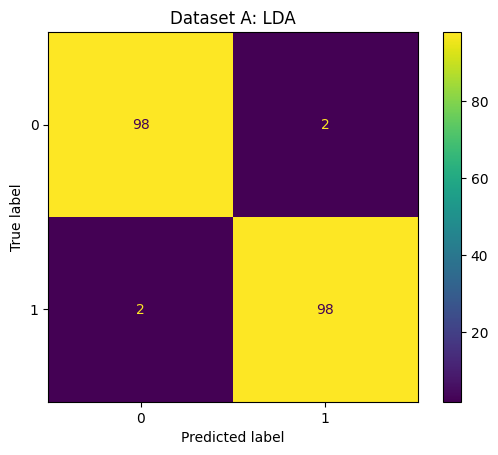


Dataset A — NB
----------------------------------------
Accuracy: 0.97
Precision macro: 0.970188075230092
Recall macro: 0.97
F1 macro: 0.96999699969997


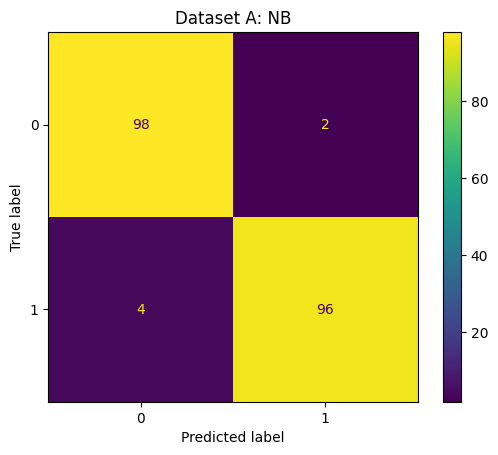


Dataset A — Logistic Regression
----------------------------------------
Accuracy: 0.99
Precision macro: 0.9901960784313726
Recall macro: 0.99
F1 macro: 0.9899989998999901


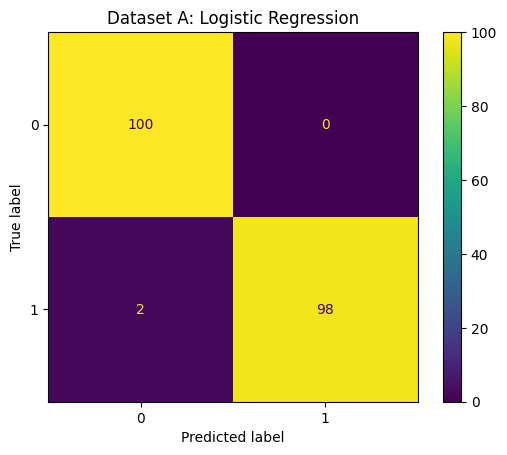


Dataset B — LDA
----------------------------------------
Accuracy: 0.98
Precision macro: 0.98
Recall macro: 0.98
F1 macro: 0.98


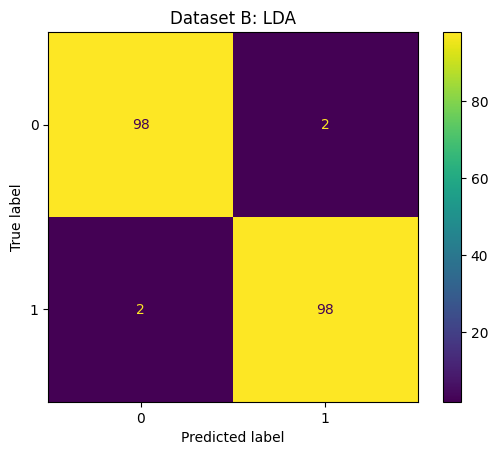


Dataset B — NB
----------------------------------------
Accuracy: 0.995
Precision macro: 0.995049504950495
Recall macro: 0.995
F1 macro: 0.9949998749968749


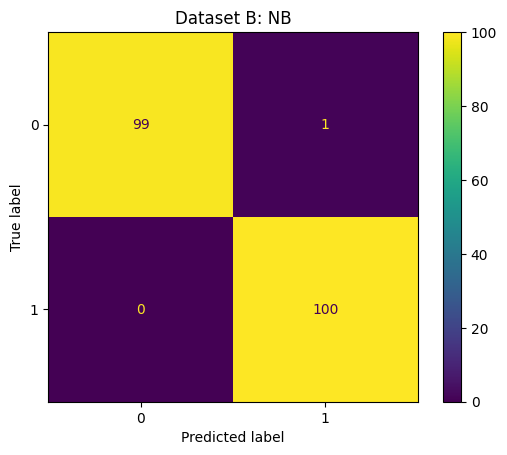


Dataset B — Logistic Regression
----------------------------------------
Accuracy: 0.975
Precision macro: 0.975427885096587
Recall macro: 0.975
F1 macro: 0.9749943737340903


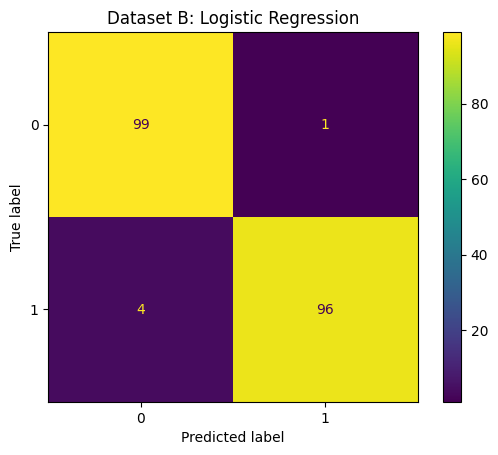


Dataset C — LDA
----------------------------------------
Accuracy: 0.89
Precision macro: 0.895698051948052
Recall macro: 0.8899999999999999
F1 macro: 0.8896025692492975


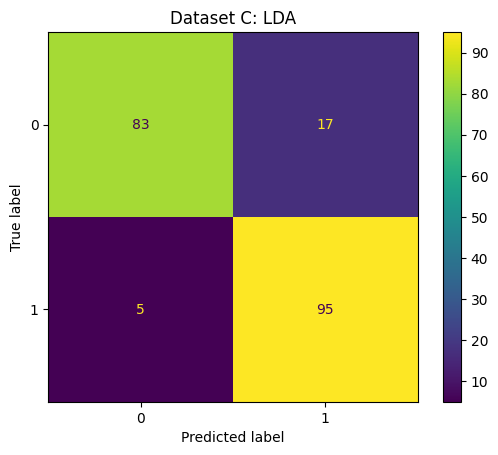


Dataset C — NB
----------------------------------------
Accuracy: 0.91
Precision macro: 0.9141414141414141
Recall macro: 0.9099999999999999
F1 macro: 0.9097744360902256


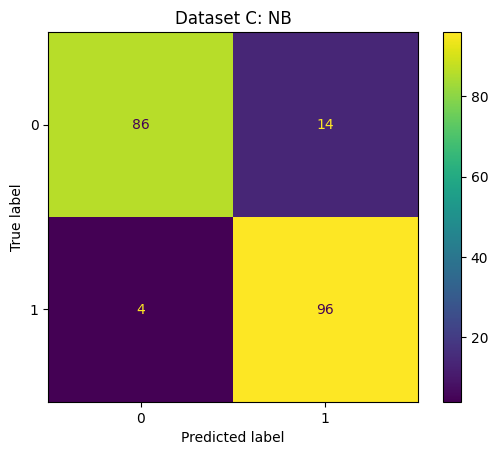


Dataset C — Logistic Regression
----------------------------------------
Accuracy: 0.915
Precision macro: 0.9160401002506267
Recall macro: 0.915
F1 macro: 0.9149468417761101


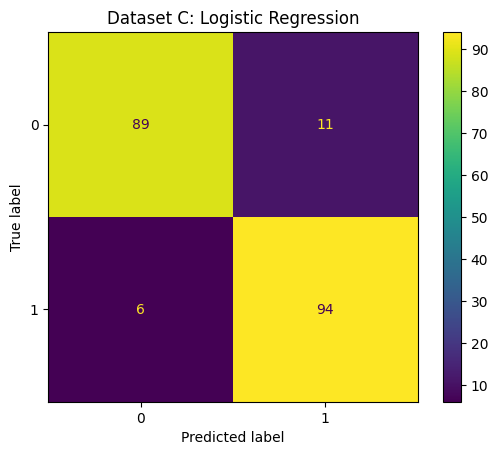

In [33]:
results_A = evaluate_dataset(X_A, y_A, "Dataset A")
results_B = evaluate_dataset(X_B, y_B, "Dataset B")
results_C = evaluate_dataset(X_C, y_C, "Dataset C")

In [34]:
import pandas as pd

def results_to_dataframe(results):
    rows = []

    for model, metrics in results.items():
        rows.append({
            "Model": model,
            "Accuracy": metrics["accuracy"],
            "Precision macro": metrics["precision_macro"],
            "Recall macro": metrics["recall_macro"],
            "F1 macro": metrics["f1_macro"]
        })

    return pd.DataFrame(rows)

df_A = results_to_dataframe(results_A)
df_B = results_to_dataframe(results_B)
df_C = results_to_dataframe(results_C)

print("DATASET A")
display(df_A)

print("DATASET B")
display(df_B)

print("DATASET C")
display(df_C)

DATASET A


,Model,Accuracy,Precision macro,Recall macro,F1 macro
0,LDA,0.98,0.980000,0.98,0.980000
1,NB,0.97,0.970188,0.97,0.969997
2,Logistic Regression,0.99,0.990196,0.99,0.989999


DATASET B


,Model,Accuracy,Precision macro,Recall macro,F1 macro
0,LDA,0.980,0.980000,0.980,0.980000
1,NB,0.995,0.995050,0.995,0.995000
2,Logistic Regression,0.975,0.975428,0.975,0.974994


DATASET C


,Model,Accuracy,Precision macro,Recall macro,F1 macro
0,LDA,0.890,0.895698,0.890,0.889603
1,NB,0.910,0.914141,0.910,0.909774
2,Logistic Regression,0.915,0.916040,0.915,0.914947


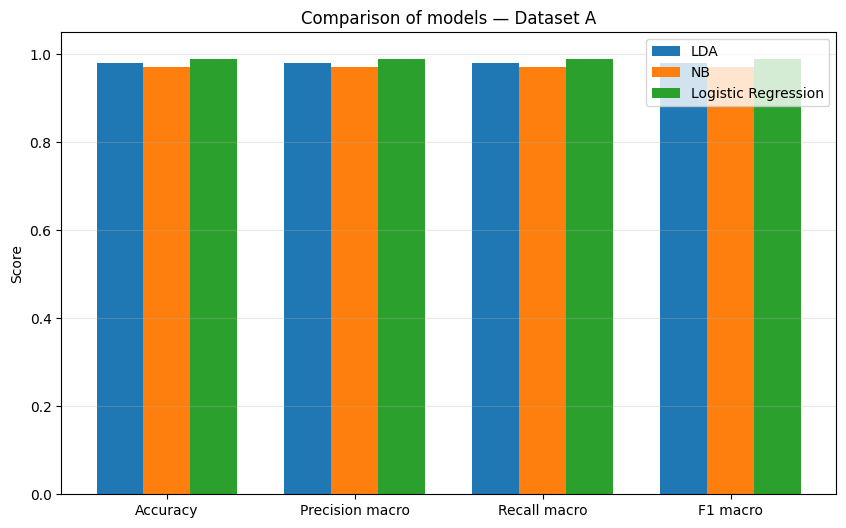

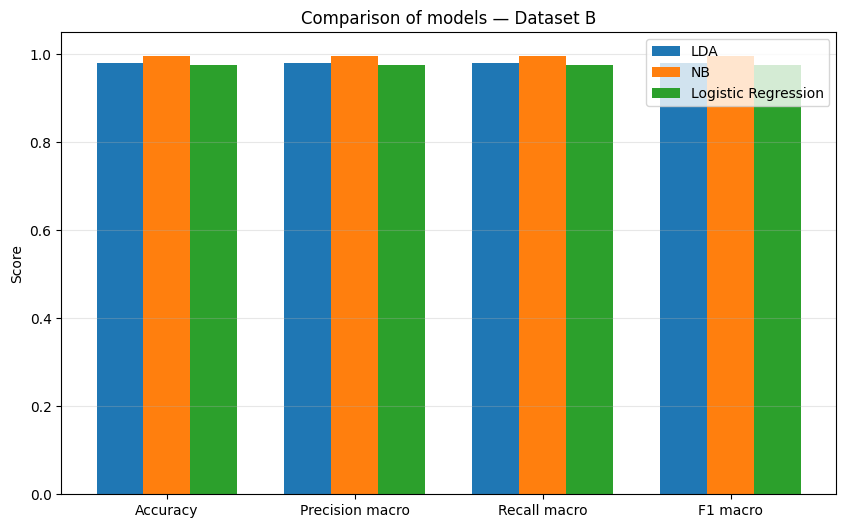

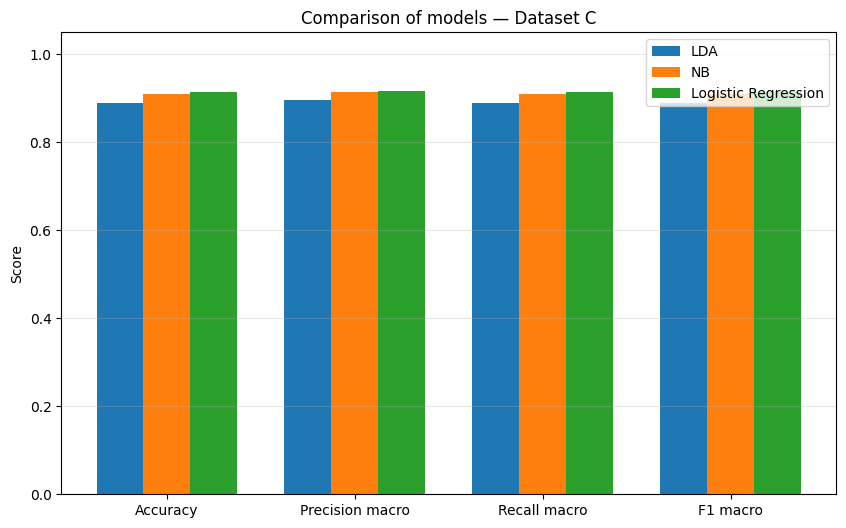

In [35]:
def plot_metrics(results, dataset_name):
    df = results_to_dataframe(results)

    metrics = [
        "Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ]

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(10, 6))

    for i, model in enumerate(df["Model"]):
        values = df.loc[df["Model"] == model, metrics].values[0]

        plt.bar(
            x + (i - 1) * width,
            values,
            width,
            label=model
        )

    plt.xticks(x, metrics)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(f"Comparison of models — {dataset_name}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    plt.show()

plot_metrics(results_A, "Dataset A")
plot_metrics(results_B, "Dataset B")
plot_metrics(results_C, "Dataset C")

## Вывод

В эксперименте были рассмотрены три типа данных, различающиеся структурой ковариаций признаков. Это позволило проверить, насколько хорошо предположения моделей LDA и Naive Bayes соответствуют реальной структуре данных.

**На датасете A LDA должен показывать наилучший результат.** Для этого датасета ковариационные матрицы двух классов одинаковы, то есть $C_0=C_1$, а различаются в основном средние значения. Это соответствует основному предположению LDA. В результате LDA может использовать общую оценку ковариационной матрицы и строить оптимальную в рамках модели линейную разделяющую границу. Naive Bayes использует более сильное предположение о независимости признаков, которое здесь не выполняется полностью из-за наличия корреляций. Поэтому NB может терять качество по сравнению с LDA.

**На датасете B преимущество ожидается у Naive Bayes.** В этом случае признаки независимы внутри каждого класса, поэтому ковариационные матрицы являются диагональными. Именно такую структуру предполагает Gaussian Naive Bayes. При этом ковариации классов различаются, то есть $C_0\neq C_1$. Это нарушает предположение LDA об общей ковариационной матрице. Следовательно, NB получает преимущество за счёт более подходящей модели распределения признаков.

**Логистическая регрессия используется как дополнительный benchmark.** Как и LDA при одинаковых ковариациях, логистическая регрессия строит линейную разделяющую поверхность. Поэтому на линейно разделимых данных она может показывать результаты, близкие к LDA. Однако она не моделирует непосредственно распределение признаков внутри классов и поэтому имеет другую статистическую основу.

**Увеличение размерности пространства до 10 признаков влияет на обе модели.** С одной стороны, большое число признаков позволяет использовать больше информации для классификации. С другой стороны, необходимо оценивать значительно больше параметров. Для LDA требуется оценивать общую ковариационную матрицу, содержащую $d(d+1)/2$ независимых параметров. При $d=10$ это уже 55 параметров только для ковариационной матрицы. Поэтому при небольшом размере обучающей выборки оценка ковариации может становиться менее устойчивой.

Для Naive Bayes ситуация проще: благодаря предположению независимости признаков вместо полной ковариационной матрицы необходимо оценивать только одну дисперсию для каждого признака в каждом классе. Поэтому число параметров растёт приблизительно линейно с размерностью. Это является одним из главных преимуществ Naive Bayes в задачах с большим количеством признаков.

**На датасете C обе модели работают хуже**, поскольку одновременно нарушаются их основные предположения. У классов разные ковариационные матрицы, что нарушает предположение LDA об общей ковариации. Кроме того, признаки коррелированы, поэтому диагональная ковариационная структура Naive Bayes также не соответствует данным. Дополнительные 5% зашумленных меток (`flip_y=0.05`) ещё сильнее ограничивают максимально достижимое качество классификации.

Таким образом, эксперимент подтверждает важный принцип: **качество классификатора зависит не только от количества признаков, но и от соответствия его статистических предположений реальной структуре данных**. LDA наиболее естественен при общей ковариации классов, Naive Bayes — при условной независимости признаков, а при сложной коррелированной структуре с различными ковариациями обе модели могут терять качество.
